**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("data.table")))
suppressMessages(suppressWarnings(library("pheatmap")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [3]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "*XY_*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_shap.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot

### Import data: variant delta

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv.gz"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_region_variant = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977      10


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272


### Import data: X (gain & loss)

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_X_gain.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_X_gain = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99102   667


Variant_ID,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP,AC0449:TIGD:CENPB,AC0495:CTCF/CTCFL:C2H2_ZF,AC0576:ZSCAN/ZNF:C2H2_ZF,AC0629:DBP/HLF:bZIP,AC0631:ATF/CREB:bZIP,AC0634:CREB/JUND:bZIP,AC0688:HSF:HSF,AC0148:BPTF/ZNF:Unknown,AC0162:ZNF:C2H2_ZF,AC0258:NRL/MAFG:bZIP,AC0313:ZBED:BED_ZF,AC0314:ZNF385D:C2H2_ZF,AC0358:ZNF:C2H2_ZF,AC0374:ARID5B:ARID/BRIGHT,AC0460:IRX:Homeodomain,AC0461:ASCL:bHLH,AC0555:NRF:Unknown,AC0597:SMAD:SMAD,AC0632:CREB:bZIP,AC0070:ZNF:C2H2_ZF,AC0144:ZNF:C2H2_ZF,AC0256:MAFF/MAF:bZIP,AC0271:PROX:Prospero,AC0410:ZNF:C2H2_ZF,AC0476:IRX:Homeodomain,AC0085:ZNF:C2H2_ZF,AC0110:NR2F/NR1H:Nuclear_receptor,AC0238:PBX/PKNOX:Homeodomain,AC0259:MAFG/MAFF:bZIP,AC0362:FOXG/FOXK:Forkhead,AC0584:ZSCAN:C2H2_ZF,AC0603:ZNF:C2H2_ZF,AC0047:ZNF:C2H2_ZF,AC0074:ZBTB/TWIST:C2H2_ZF,AC0077:LYL/OLIG:bHLH,AC0080:ZNF:C2H2_ZF,AC0081:SCRT:C2H2_ZF,AC0149:ZNF:C2H2_ZF,AC0193:ZNF:C2H2_ZF,AC0194:CTCF:C2H2_ZF,AC0450:ZBTB:C2H2_ZF,AC0579:ZNF:C2H2_ZF,AC0587:ZNF:C2H2_ZF,AC0492:TBX/T:T-box,AC0111:NR1H:Nuclear_receptor,AC0161:ZNF:C2H2_ZF,AC0475:TP:p53,AC0485:FOSL:bZIP,AC0599:ZKSCAN:C2H2_ZF,"AC0089:POU4F:Homeodomain,POU","AC0101:POU3F/POU2F:Homeodomain,POU",AC0184:ZNF:C2H2_ZF,"AC0230:POU2F/ZNF:Homeodomain,POU",AC0651:ZNF:C2H2_ZF,AC0039:FOXD/FOXK:Forkhead,AC0268:GMEB:SAND,AC0578:ZNF:C2H2_ZF,AC0628:CEBPB/CEBPE:bZIP,AC0045:ZNF:C2H2_ZF,"AC0076:ERF::FIGLA/ETV2::FIGLA:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0127:TCF7L/LEF:Sox,AC0133:NR6A:Nuclear_receptor,"AC0636:POU5F/NANOG:Homeodomain,POU",AC0124:RARA/RARG:Nuclear_receptor,AC0231:ZNF:C2H2_ZF,AC0233:ZNF:C2H2_ZF,AC0401:ZNF:C2H2_ZF,AC0513:ZNF:C2H2_ZF,AC0559:ZNF:C2H2_ZF,AC0594:ZNF:C2H2_ZF,AC0200:ZNF:C2H2_ZF,AC0202:ZNF:C2H2_ZF,"AC0483:PAX:Homeodomain,Paired_box","AC0484:PAX:Homeodomain,Paired_box",AC0494:ZIC/GLIS:C2H2_ZF,AC0367:ZNF:C2H2_ZF,AC0512:YY:C2H2_ZF,AC0213:ZNF:C2H2_ZF,AC0237:ZNF:C2H2_ZF,AC0260:IRX:Homeodomain,AC0481:ZNF:C2H2_ZF,AC0504:ZNF:C2H2_ZF,"AC0515:PAX:Homeodomain,Paired_box",AC0046:BACH/NFE:bZIP,AC0096:PBX/HOXA:Homeodomain,AC0098:MEIS/PBX:Homeodomain,AC0113:RARA/ESRRA:Nuclear_receptor,AC0115:NR1I/NR1H:Nuclear_receptor,AC0551:CENPB:CENPB,AC0568:ZNF:C2H2_ZF,AC0049:JUND/JUN:bZIP,AC0234:ZNF:C2H2_ZF,AC0269:FOXN:Forkhead,AC0366:ZNF:C2H2_ZF,AC0488:TBX:T-box,AC0511:YY/ZFP:C2H2_ZF,AC0192:ZIK:C2H2_ZF,AC0024:POU3F/HESX:Homeodomain,AC0165:ZNF:C2H2_ZF,AC0300:ZNF:C2H2_ZF,AC0118:THRA/THRB:Nuclear_receptor,AC0120:THRB:Nuclear_receptor,AC0122:ESR/ESRRA:Nuclear_receptor,AC0123:NR1D/RORC:Nuclear_receptor,AC0155:ZNF:C2H2_ZF,AC0257:ZNF:C2H2_ZF,AC0289:RFX/MXI:RFX,AC0390:ZFP:C2H2_ZF,AC0666:IRF:IRF,AC0009:DUXA/DUX:Homeodomain,AC0163:NR1D:Nuclear_receptor,AC0502:ZNF:C2H2_ZF,AC0520:ZNF/EGR:C2H2_ZF,AC0581:ZNF:C2H2_ZF,AC0591:ZNF:C2H2_ZF,AC0655:RUNX:Runt,AC0075:MYOD/MYOG:bHLH,AC0182:ZNF:C2H2_ZF,AC0108:RXRG/RARB:Nuclear_receptor,AC0136:NR2E:Nuclear_receptor,AC0222:ZNF/ZFP:C2H2_ZF,AC0507:ZNF:C2H2_ZF,AC0353:ZSCAN:C2H2_ZF,AC0550:GCM:GCM,AC0557:ZNF:C2H2_ZF,AC0196:ZNF:C2H2_ZF,AC0284:DMRT/DMRTA:DM,AC0641:ETV/ETS:Ets,AC0642:SPIB/SPI:Ets,AC0275:MYB/MYBL:Myb/SANT,AC0010:PROP/ALX:Homeodomain,AC0028:ZNF:C2H2_ZF,AC0109:ZNF:C2H2_ZF,AC0505:ZSCAN:C2H2_ZF,AC0589:ZNF:C2H2_ZF,AC0487:TBX/T:T-box,AC0530:ZSCAN/KLF:C2H2_ZF,AC0169:ZNF:C2H2_ZF,AC0396:MYRF:Ndt80/PhoG,AC0549:GCM:GCM,AC0570:ZNF:C2H2_ZF,AC0583:ZNF:C2H2_ZF,AC0595:ZNF:C2H2_ZF,AC0086:MEIS/PKNOX:Homeodomain,AC0459:SIX/ZNF:Homeodomain,AC0025:ZNF:C2H2_ZF,AC0677:BCL11A/IRF:C2H2_ZF,"AC0102:POU2F/POU3F:Homeodomain,POU",AC0180:ZNF:C2H2_ZF,AC0430:ZNF:C2H2_ZF,AC0531:ZNF:C2H2_ZF,AC0019:TLX/PAX:Homeodomain,AC0226:ZNF:C2H2_ZF,AC0413:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0050:ZSCAN5C:C2H2_ZF,AC0051:BATF/IRF:bZIP,AC0135:NR2E:Nuclear_receptor,AC0468:ZNF:C2H2_ZF,AC0590:ZNF:C2H2_ZF,AC0352:ZNF:C2H2_ZF,AC0387:ZFP:C2H2_ZF,AC0510:YY/MZF:C2H2_ZF,AC0388:ZNF:C2H2_ZF,AC0094:NR1H/WT:Nuclear_receptor,AC0205:ZNF:C2H2_ZF,AC0206:ZNF:C2

In [5]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_X_loss.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_X_loss = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99033   667


Variant_ID,AC0013:ZNF:C2H2_ZF,AC0124:RARA/RARG:Nuclear_receptor,AC0157:ZNF:C2H2_ZF,AC0164:ZFP:C2H2_ZF,AC0167:ZNF780A:C2H2_ZF,AC0185:ZFP/ZFP69B:C2H2_ZF,AC0188:ZNF:C2H2_ZF,AC0224:ZNF:C2H2_ZF,AC0360:MBNL:CCCH_ZF,AC0364:ZFP:C2H2_ZF,AC0425:ZNF:C2H2_ZF,AC0527:GLIS:C2H2_ZF,AC0558:ZNF:C2H2_ZF,AC0560:ZNF:C2H2_ZF,AC0563:ZNF/RBAK:C2H2_ZF,AC0571:ZNF/PRDM:C2H2_ZF,AC0573:ZNF:C2H2_ZF,AC0615:ZNF:C2H2_ZF,AC0641:ETV/ETS:Ets,AC0678:ZNF:C2H2_ZF,AC0144:ZNF:C2H2_ZF,AC0161:ZNF:C2H2_ZF,AC0192:ZIK:C2H2_ZF,AC0206:ZNF:C2H2_ZF,AC0300:ZNF:C2H2_ZF,AC0344:ZKSCAN:C2H2_ZF,AC0435:HIC:C2H2_ZF,AC0445:ZNF:C2H2_ZF,"AC0447:ZKSCAN:C2H2_ZF,MADF",AC0457:ZNF:C2H2_ZF,AC0498:TFAP2C/TFAP2A:AP-2,AC0506:ZNF:C2H2_ZF,AC0524:KLF/SP:C2H2_ZF,AC0525:ZNF/MAZ:C2H2_ZF,AC0538:ZNF:C2H2_ZF,AC0559:ZNF:C2H2_ZF,AC0572:ZNF:C2H2_ZF,"AC0574:PAX:Homeodomain,Paired_box",AC0576:ZSCAN/ZNF:C2H2_ZF,AC0579:ZNF:C2H2_ZF,AC0589:ZNF:C2H2_ZF,AC0594:ZNF:C2H2_ZF,AC0611:ZNF:C2H2_ZF,AC0613:ZNF:C2H2_ZF,AC0655:RUNX:Runt,AC0028:ZNF:C2H2_ZF,AC0046:BACH/NFE:bZIP,AC0232:ZNF33B:C2H2_ZF,AC0488:TBX:T-box,AC0509:ZNF:C2H2_ZF,AC0205:ZNF:C2H2_ZF,"AC0230:POU2F/ZNF:Homeodomain,POU",AC0404:ZNF:C2H2_ZF,AC0424:ZNF:C2H2_ZF,AC0556:ZFP:C2H2_ZF,AC0677:BCL11A/IRF:C2H2_ZF,AC0049:JUND/JUN:bZIP,AC0163:NR1D:Nuclear_receptor,AC0173:ZNF:C2H2_ZF,AC0235:ZNF:C2H2_ZF,AC0366:ZNF:C2H2_ZF,AC0448:ZNF:C2H2_ZF,AC0462:ZBTB/ZNF:C2H2_ZF,AC0499:TFAP2A/TFAP2C:AP-2,AC0502:ZNF:C2H2_ZF,AC0507:ZNF:C2H2_ZF,"AC0515:PAX:Homeodomain,Paired_box",AC0566:ZNF:C2H2_ZF,AC0569:ZNF:C2H2_ZF,AC0584:ZSCAN:C2H2_ZF,AC0617:ZNF:C2H2_ZF,AC0169:ZNF:C2H2_ZF,AC0186:ZBTB:C2H2_ZF,AC0241:GFI/GFI1B:C2H2_ZF,AC0585:ZNF:C2H2_ZF,"AC0011:POU3F:Homeodomain,POU","AC0076:ERF::FIGLA/ETV2::FIGLA:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0123:NR1D/RORC:Nuclear_receptor,AC0184:ZNF:C2H2_ZF,AC0372:ZNF:C2H2_ZF,AC0375:ZBTB:C2H2_ZF,AC0390:ZFP:C2H2_ZF,AC0578:ZNF:C2H2_ZF,AC0588:ZNF:C2H2_ZF,AC0596:ZNF:C2H2_ZF,AC0059:RHOXF/DPRX:Homeodomain,AC0146:ZNF:C2H2_ZF,AC0236:ZNF:C2H2_ZF,AC0353:ZSCAN:C2H2_ZF,AC0370:ZNF:C2H2_ZF,AC0570:ZNF:C2H2_ZF,AC0618:ZNF:C2H2_ZF,AC0118:THRA/THRB:Nuclear_receptor,AC0120:THRB:Nuclear_receptor,AC0196:ZNF:C2H2_ZF,AC0202:ZNF:C2H2_ZF,AC0297:MEF2B/MEF2C:MADS_box,AC0051:BATF/IRF:bZIP,AC0110:NR2F/NR1H:Nuclear_receptor,AC0142:ZNF:C2H2_ZF,AC0480:NFIX/NFIC:SMAD,AC0494:ZIC/GLIS:C2H2_ZF,AC0495:CTCF/CTCFL:C2H2_ZF,AC0508:ZNF:C2H2_ZF,AC0096:PBX/HOXA:Homeodomain,AC0204:ZNF:C2H2_ZF,AC0226:ZNF:C2H2_ZF,AC0250:ZNF:C2H2_ZF,AC0292:RFX:RFX,AC0333:XPA:Unknown,AC0413:ZNF:C2H2_ZF,AC0597:SMAD:SMAD,AC0610:FOXO:Forkhead,AC0070:ZNF:C2H2_ZF,AC0162:ZNF:C2H2_ZF,AC0165:ZNF:C2H2_ZF,AC0172:ZNF:C2H2_ZF,AC0290:RFX:RFX,AC0304:ZNF:C2H2_ZF,AC0504:ZNF:C2H2_ZF,AC0565:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0676:ZFP:C2H2_ZF,AC0174:CTCF/ZNF:C2H2_ZF,AC0194:CTCF:C2H2_ZF,AC0195:ZNF:C2H2_ZF,AC0444:ZNF:C2H2_ZF,AC0467:ZNF:C2H2_ZF,AC0587:ZNF:C2H2_ZF,AC0684:STAT:STAT,AC0259:MAFG/MAFF:bZIP,AC0289:RFX/MXI:RFX,AC0221:ZNF/PRDM:C2H2_ZF,AC0561:FLI/ZNF:Ets,AC0672:IRF/STAT:IRF,AC0240:NFYA/NFYB:CBF/NF-Y,AC0308:LEF/TCF:Sox,AC0557:ZNF:C2H2_ZF,AC0097:HOXB/PBX:Homeodomain,AC0225:ZFP:C2H2_ZF,AC0234:ZNF:C2H2_ZF,AC0686:HSF/NFATC:HSF,AC0019:TLX/PAX:Homeodomain,AC0113:RARA/ESRRA:Nuclear_receptor,AC0117:THRB:Nuclear_receptor,AC0171:ZNF:C2H2_ZF,AC0469:ZNF/ZNF280A:C2H2_ZF,AC0590:ZNF:C2H2_ZF,AC0592:ZNF/ZNF324B:['C2H2_zinc_finger_factors'],AC0605:ZBTB:C2H2_ZF,AC0657:RUNX:Runt,AC0002:EMX/PAX:Homeodomain,AC0222:ZNF/ZFP:C2H2_ZF,AC0291:RFX:RFX,AC0537:ZNF:C2H2_ZF,AC0580:ZNF:C2H2_ZF,AC0691:RELA/NFKB:Rel,AC0417:ZNF:C2H2_ZF,AC0531:ZNF:C2H2_ZF,AC0347:ZNF:C2H2_ZF,AC0606:ZNF:C2H2_ZF,AC0170:ZNF:C2H2_ZF,"AC0079:ERF::NHLH:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0149:ZNF:C2H2_ZF,AC0306:ZNF:C2H2_ZF,AC0449:TIGD:CENPB,AC0687:ZBTB:C2H2_ZF,AC0050:ZSCAN5C:C2H2_ZF,AC0116:THRB/ESRRA:Nuclear_receptor,AC0187:ZNF:C2H2_ZF,AC0008:GATA:GATA,AC0071:ZBTB:C2H2_ZF,AC0155:ZNF:C2H2_ZF,AC0229:ZNF:C2H2_ZF,AC0137:REST:C2H2_ZF,AC0193:ZNF:C2H2_ZF,AC0223:ZNF:C2H2_ZF,AC0296:SRF:MADS_box,AC0604:ZBTB:C2H2_ZF,AC0166:ZNF:C2H2_ZF,AC0115:NR

### Import data: SHAP (gain & loss_flip)

In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xgb_gain_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 66001932        7


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0629:DBP/HLF:bZIP,0.1358403,6.198104,0.695873,0.001305,chr4:74487586:A:G:C
2,AC0629:DBP/HLF:bZIP,0.1076249,6.198104,0.695873,0.001305,chr9:135685432:G:G:C
3,AC0629:DBP/HLF:bZIP,0.1015119,6.198104,0.695873,0.001305,chr1:173251490:G:G:C


In [7]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_loss_flip_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xgb_loss_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 65955978        7


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0615:ZNF:C2H2_ZF,0.2749247,11.18755,0.9376569,0.0010525,chr4:74487586:A:G:C
2,AC0615:ZNF:C2H2_ZF,0.2967755,11.18755,0.9376567,0.0010525,chr9:135685432:G:G:C
3,AC0615:ZNF:C2H2_ZF,0.2832606,11.18755,0.9376569,0.0010525,chr1:173251490:G:G:C


### Import data: activator / repressor

In [8]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_motif_activator.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_motif_activator = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 48  7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0629:DBP/HLF:bZIP,99102,1764,0.0177998,0.0384065,0.0384283,0.0547334
AC0450:ZBTB:C2H2_ZF,99102,863,0.0087082,0.0174850,0.0175198,0.0029946
AC0273:BATF/FOSL:bZIP,99102,1610,0.0162459,0.0155743,0.0158109,0.5484898


In [9]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_motif_repressor.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_motif_repressor = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 46  7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0615:ZNF:C2H2_ZF,99033,3293,0.0332515,0.0185503,0.0186303,0.4628799
AC0613:ZNF:C2H2_ZF,99033,1595,0.0161057,0.0095472,0.0096139,0.5178587
AC0241:GFI/GFI1B:C2H2_ZF,99033,1888,0.0190644,0.0046111,0.0046242,0.3098360


## Filter SHAP rows for those motifs

In [10]:
### init: get activators from gain model
vec_txt_motif_act = dat_motif_activator$variable

### init: get activators from gain model
vec_txt_motif_rep = dat_motif_repressor$variable

### init: get quantile threshold
num_quantile = 0.99

**top SHAP values and corresponding variants**

In [11]:
### filter SHAP values of variant-motif pair by activator
dat = dat_xgb_gain_shap
dat = dat %>% dplyr::filter(variable %in% vec_txt_motif_act)

### choose strong SHAP variants
num = quantile(abs(dat$value), num_quantile, na.rm = TRUE)
dat = dat %>% dplyr::filter(rfvalue > 0, abs(value) >= num)
vec = unique(dat$Variant_ID)

### assign and show
vec_txt_variant_act      = vec
dat_xgb_gain_shap_filter = dat
print(dim(dat))
print(length(vec))
fun_display_table(head(dat))

[1] 28591     7
[1] 22744


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0629:DBP/HLF:bZIP,0.1358403,6.198104,0.6958730,0.001305,chr4:74487586:A:G:C
2,AC0629:DBP/HLF:bZIP,0.1076249,6.198104,0.6958730,0.001305,chr9:135685432:G:G:C
3,AC0629:DBP/HLF:bZIP,0.1015119,6.198104,0.6958730,0.001305,chr1:173251490:G:G:C
4,AC0629:DBP/HLF:bZIP,0.0995344,6.198104,0.6958730,0.001305,chr1:147523391:G:G:C
5,AC0629:DBP/HLF:bZIP,0.2407217,4.409525,0.4950657,0.001305,chr18:54580749:A:G:T
6,AC0629:DBP/HLF:bZIP,0.0694715,6.198104,0.6958730,0.001305,chr7:80949454:A:G:C


**top SHAP values and corresponding variants**

In [12]:
### filter SHAP values of variant-motif pair by repressor
dat = dat_xgb_loss_shap
dat = dat %>% dplyr::filter(variable %in% vec_txt_motif_rep)

### choose strong SHAP variants
num = quantile(abs(dat$value), num_quantile, na.rm = TRUE)
dat = dat %>% dplyr::filter(rfvalue > 0, abs(value) >= num)
vec = unique(dat$Variant_ID)

### assign and show
vec_txt_variant_rep      = vec
dat_xgb_loss_shap_filter = dat
print(dim(dat))
print(length(vec))
fun_display_table(head(dat))

[1] 35985     7
[1] 27724


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0615:ZNF:C2H2_ZF,0.2749247,11.18755,0.9376569,0.0010525,chr4:74487586:A:G:C
2,AC0615:ZNF:C2H2_ZF,0.2967755,11.18755,0.9376567,0.0010525,chr9:135685432:G:G:C
3,AC0615:ZNF:C2H2_ZF,0.2832606,11.18755,0.9376569,0.0010525,chr1:173251490:G:G:C
4,AC0615:ZNF:C2H2_ZF,0.3091672,11.18755,0.9376569,0.0010525,chr1:147523391:G:G:C
5,AC0615:ZNF:C2H2_ZF,0.1992997,10.02180,0.8399525,0.0010525,chr18:54580749:A:G:T
6,AC0615:ZNF:C2H2_ZF,0.2893242,11.18755,0.9376569,0.0010525,chr7:80949454:A:G:C


### Get subset and order of variants

In [13]:
vec_txt_variant_full = intersect(dat_X_gain$Variant_ID, dat_X_loss$Variant_ID)
print(length(vec_txt_variant_full))

[1] 98175


In [17]:
vec = union(vec_txt_variant_act, vec_txt_variant_rep)
vec = intersect(vec_txt_variant_full, vec)

vec_txt_variant_subset = vec
print(length(vec))

[1] 41657


In [18]:
### filter variants
dat = dat_region_variant 
dat = dat %>% dplyr::arrange(desc(Delta))

### get the variants
vec_txt_variant_sort = dat$Variant_ID

## Get subset of motif matrix

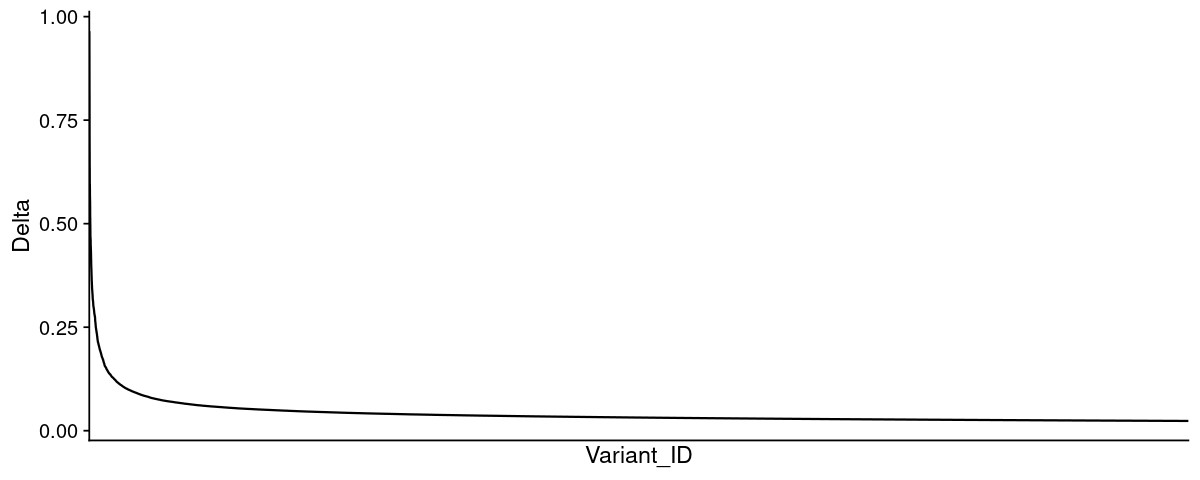

In [30]:
### filter variants
dat = dat_region_variant 
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec_txt_variant_subset) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

In [25]:
dat = dat_X_gain 
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_subset)

dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_act)
                            
dat_X_gain_subset = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 1999536       3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0270:FOXN:Forkhead,14.101769
chr4:74487586:A:G:C,AC0272:GMEB:SAND,7.153482
chr4:74487586:A:G:C,AC0273:BATF/FOSL:bZIP,7.116993
chr4:74487586:A:G:C,AC0629:DBP/HLF:bZIP,6.198104
chr4:74487586:A:G:C,AC0634:CREB/JUND:bZIP,5.782097
chr4:74487586:A:G:C,AC0256:MAFF/MAF:bZIP,0.000000


In [26]:
dat = dat_X_loss
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_subset)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_rep)
dat_X_loss_subset = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 1916222       3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0157:ZNF:C2H2_ZF,-10.82394
chr4:74487586:A:G:C,AC0615:ZNF:C2H2_ZF,-11.18755
chr4:74487586:A:G:C,AC0435:HIC:C2H2_ZF,0.00000
chr4:74487586:A:G:C,AC0613:ZNF:C2H2_ZF,0.00000
chr4:74487586:A:G:C,AC0046:BACH/NFE:bZIP,0.00000
chr4:74487586:A:G:C,AC0509:ZNF:C2H2_ZF,0.00000


In [23]:
print(1)

[1] 1


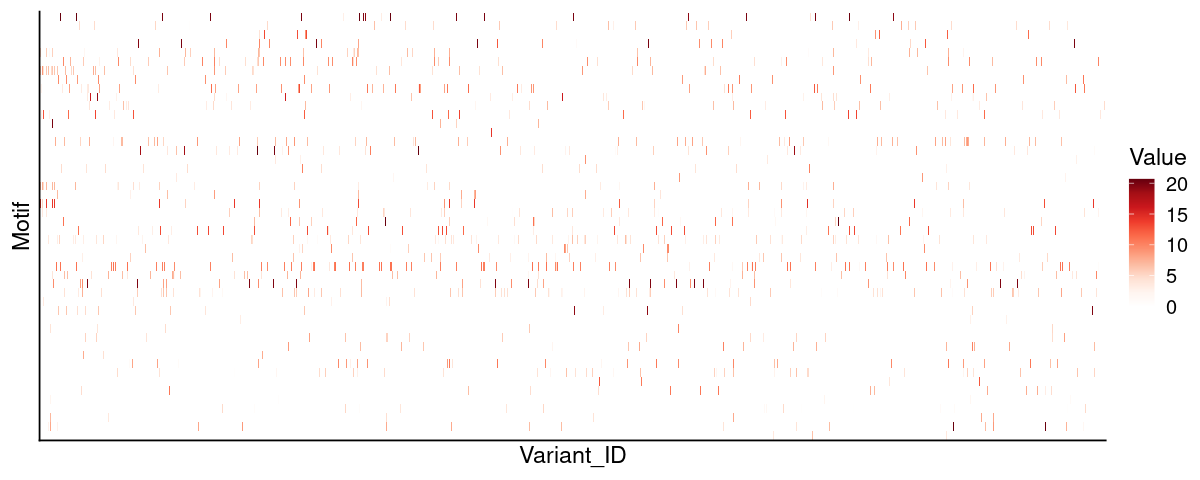

In [27]:
###
dat = dat_X_gain_subset
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_gain = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

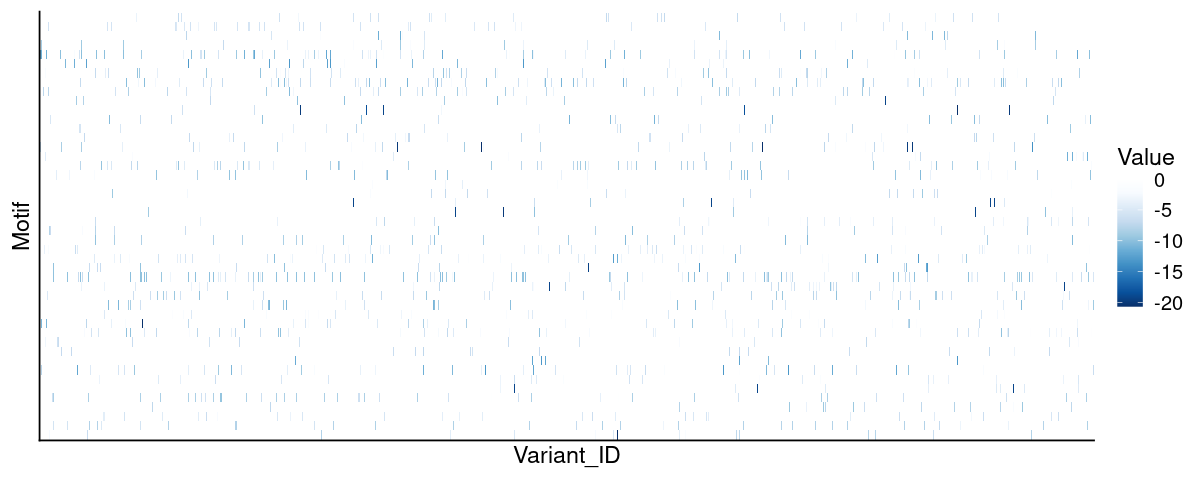

In [28]:
###
dat = dat_X_loss_subset
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_loss = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

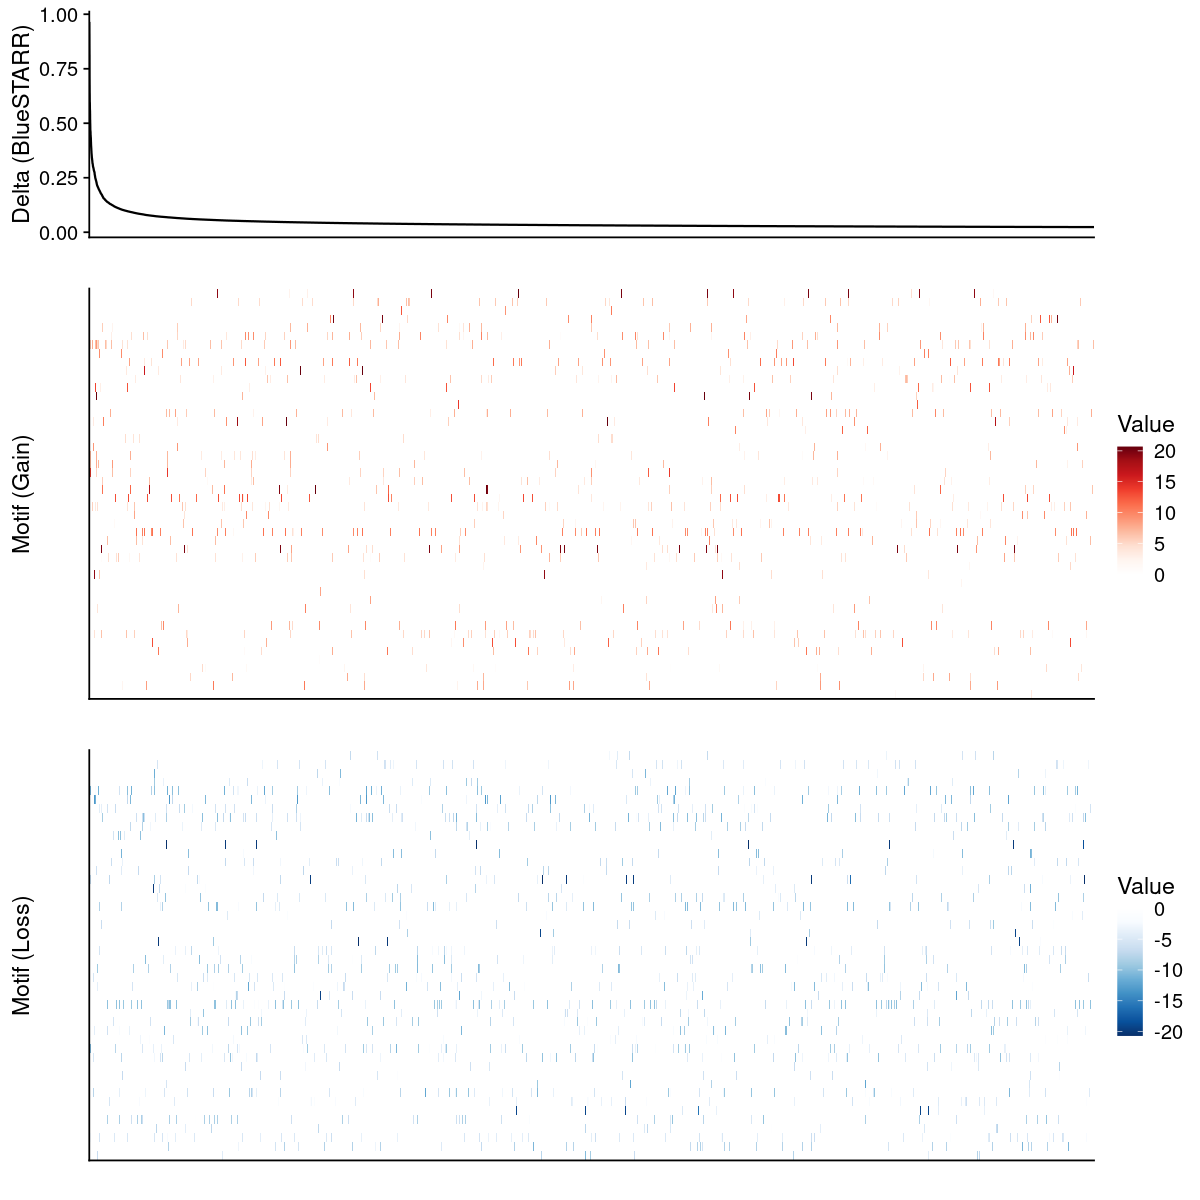

In [31]:
lst = list(
    gpt_Y      + labs(x="", y = "Delta (BlueSTARR)"), 
    gpt_X_gain + labs(x="", y = "Motif (Gain)"), 
    gpt_X_loss + labs(x="", y = "Motif (Loss)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(3, 5, 5),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=10)
print(plt)

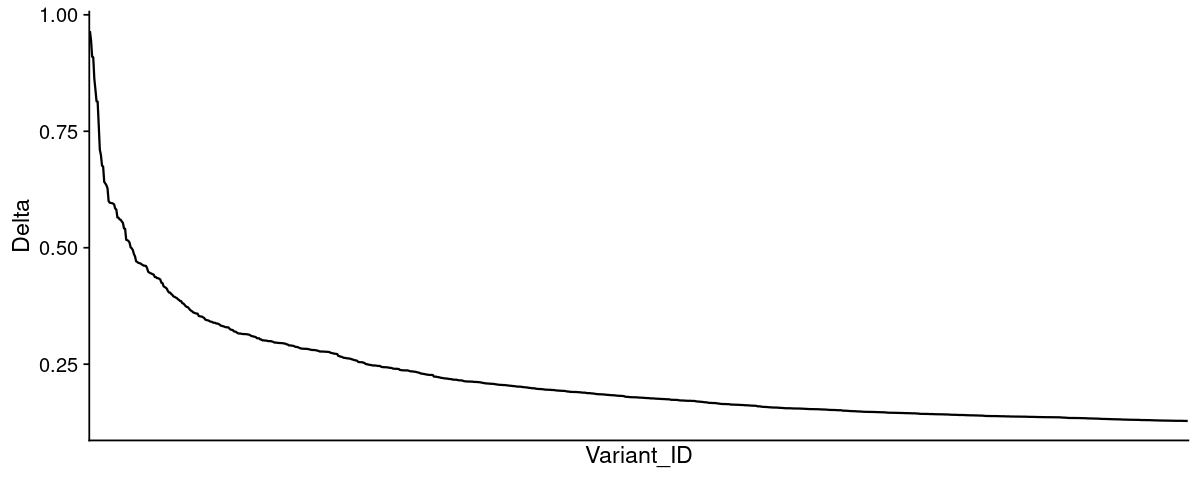

In [140]:
### filter variants
dat = dat_region_variant 
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec_txt_variant_full) %>%
    dplyr::arrange(desc(Delta)) %>%
    head(1000)

###
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

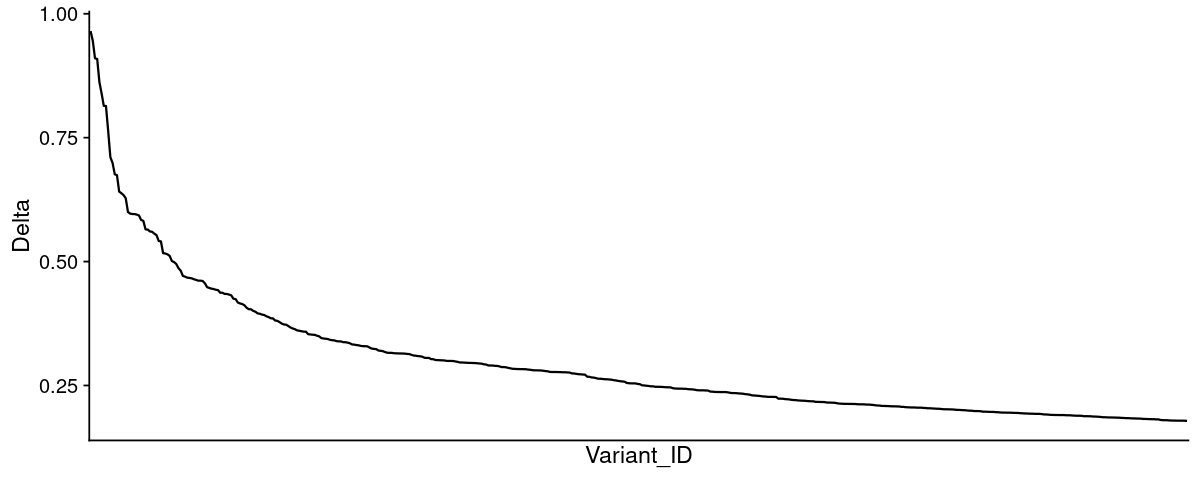

In [141]:
### filter variants
dat = dat_region_variant 
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec_txt_variant_full) %>%
    dplyr::arrange(desc(Delta)) %>%
    head(500)

### get the variants
vec_txt_variant_top = dat$Variant_ID

###
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_top))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

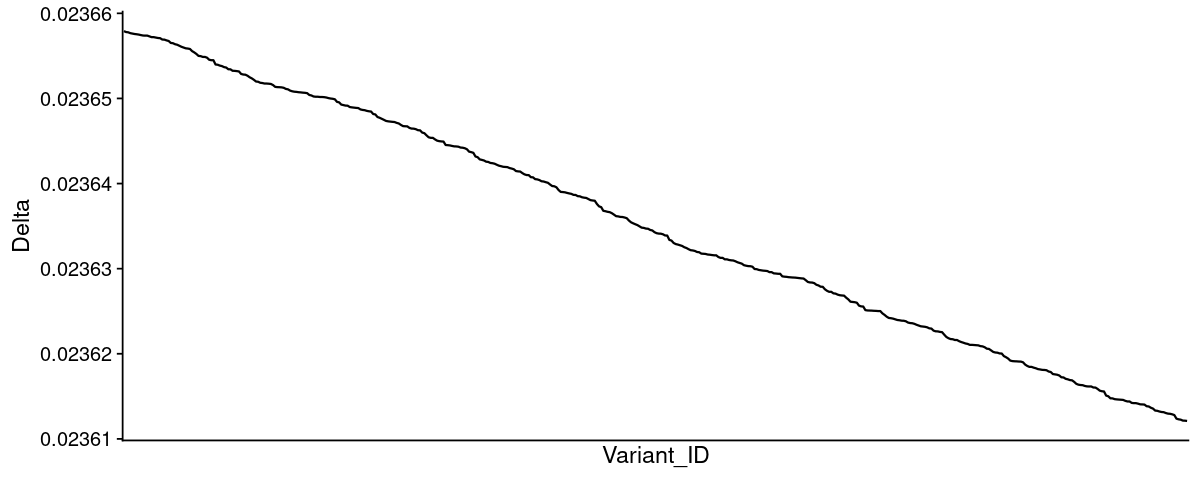

In [142]:
### filter variants
dat = dat_region_variant 
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec_txt_variant_full) %>%
    dplyr::arrange(desc(Delta)) %>%
    tail(500)

### get the variants
vec_txt_variant_low = dat$Variant_ID

###
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_low))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

In [119]:
dat = dat_X_gain 
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_sort)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_gain_subset = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 666000      3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0048:NFE2L/JUN:bZIP,1.914324
chr4:74487586:A:G:C,AC0116:THRB/ESRRA:Nuclear_receptor,6.131183
chr4:74487586:A:G:C,AC0125:NR1I/VDR:Nuclear_receptor,6.838040
chr4:74487586:A:G:C,"AC0158:PAX:Homeodomain,Paired_box",0.916502
chr4:74487586:A:G:C,AC0219:ZNF:C2H2_ZF,3.162317
chr4:74487586:A:G:C,AC0270:FOXN:Forkhead,14.101769


In [120]:
dat = dat_X_loss
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_sort)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_loss_subset = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 666000      3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0013:ZNF:C2H2_ZF,-4.556030
chr4:74487586:A:G:C,AC0124:RARA/RARG:Nuclear_receptor,-6.097351
chr4:74487586:A:G:C,AC0157:ZNF:C2H2_ZF,-10.823937
chr4:74487586:A:G:C,AC0164:ZFP:C2H2_ZF,-4.239392
chr4:74487586:A:G:C,AC0167:ZNF780A:C2H2_ZF,-10.665994
chr4:74487586:A:G:C,AC0185:ZFP/ZFP69B:C2H2_ZF,-7.273474


In [127]:
dat = dat_X_gain 
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_top)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_gain_top = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 333000      3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0048:NFE2L/JUN:bZIP,1.914324
chr4:74487586:A:G:C,AC0116:THRB/ESRRA:Nuclear_receptor,6.131183
chr4:74487586:A:G:C,AC0125:NR1I/VDR:Nuclear_receptor,6.838040
chr4:74487586:A:G:C,"AC0158:PAX:Homeodomain,Paired_box",0.916502
chr4:74487586:A:G:C,AC0219:ZNF:C2H2_ZF,3.162317
chr4:74487586:A:G:C,AC0270:FOXN:Forkhead,14.101769


In [128]:
dat = dat_X_loss
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_top)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_loss_top = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 333000      3


Variant_ID,Motif,Value
chr4:74487586:A:G:C,AC0013:ZNF:C2H2_ZF,-4.556030
chr4:74487586:A:G:C,AC0124:RARA/RARG:Nuclear_receptor,-6.097351
chr4:74487586:A:G:C,AC0157:ZNF:C2H2_ZF,-10.823937
chr4:74487586:A:G:C,AC0164:ZFP:C2H2_ZF,-4.239392
chr4:74487586:A:G:C,AC0167:ZNF780A:C2H2_ZF,-10.665994
chr4:74487586:A:G:C,AC0185:ZFP/ZFP69B:C2H2_ZF,-7.273474


In [129]:
dat = dat_X_gain 
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_low)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_gain_low = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 333000      3


Variant_ID,Motif,Value
chr9:89317122:C:T:A,AC0048:NFE2L/JUN:bZIP,0
chr9:89317122:C:T:A,AC0116:THRB/ESRRA:Nuclear_receptor,0
chr9:89317122:C:T:A,AC0125:NR1I/VDR:Nuclear_receptor,0
chr9:89317122:C:T:A,"AC0158:PAX:Homeodomain,Paired_box",0
chr9:89317122:C:T:A,AC0219:ZNF:C2H2_ZF,0
chr9:89317122:C:T:A,AC0270:FOXN:Forkhead,0


In [130]:
dat = dat_X_loss
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_low)
dat = dat %>% tidyr::pivot_longer(
    cols = starts_with("AC"),
    names_to  = "Motif",
    values_to = "Value"
)

dat_X_loss_low = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 333000      3


Variant_ID,Motif,Value
chr9:89317122:C:T:A,AC0013:ZNF:C2H2_ZF,0
chr9:89317122:C:T:A,AC0124:RARA/RARG:Nuclear_receptor,0
chr9:89317122:C:T:A,AC0157:ZNF:C2H2_ZF,0
chr9:89317122:C:T:A,AC0164:ZFP:C2H2_ZF,0
chr9:89317122:C:T:A,AC0167:ZNF780A:C2H2_ZF,0
chr9:89317122:C:T:A,AC0185:ZFP/ZFP69B:C2H2_ZF,0


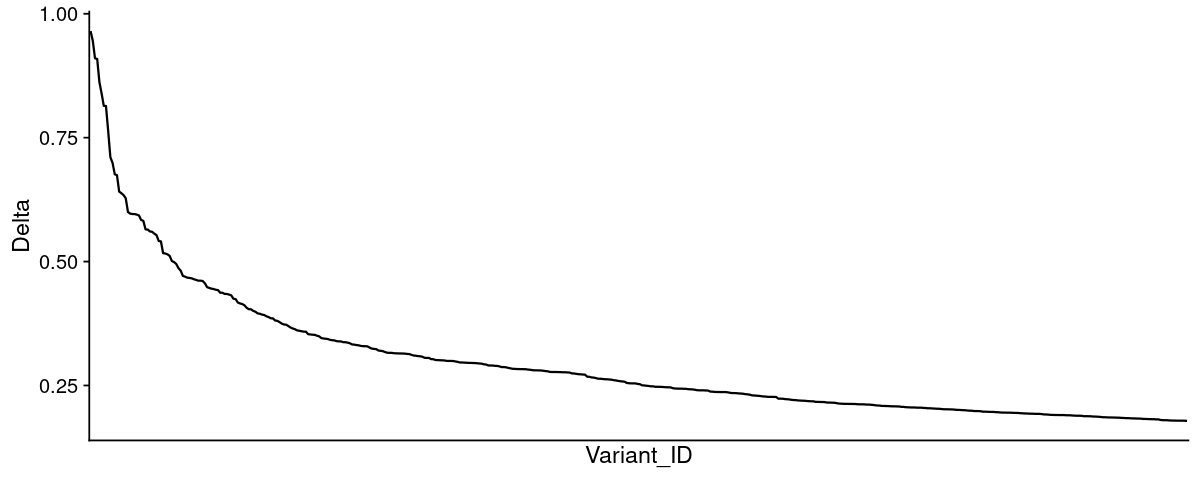

In [121]:
dat = dat_region_variant_subset
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

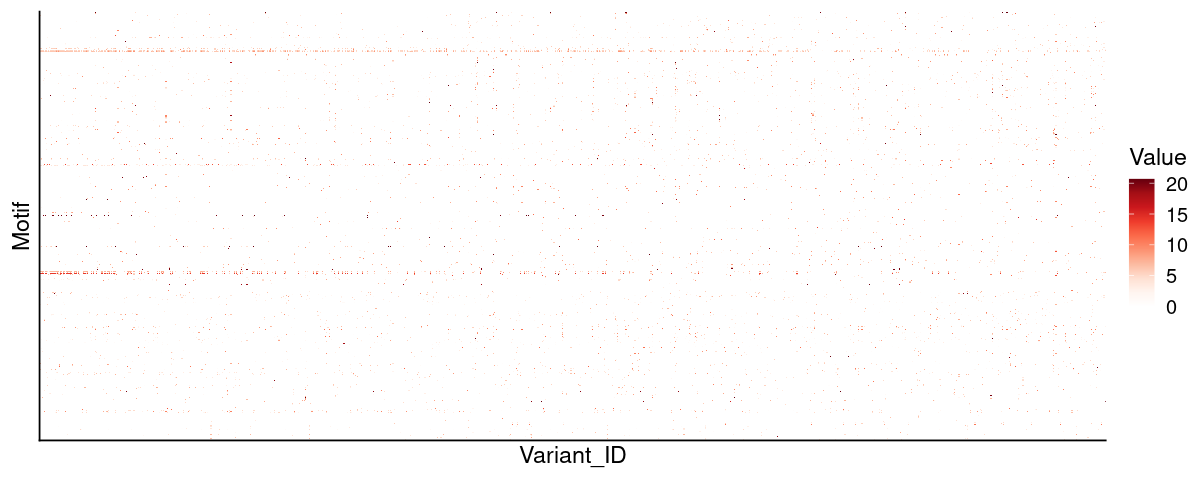

In [122]:
###
dat = dat_X_gain_subset
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_gain = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

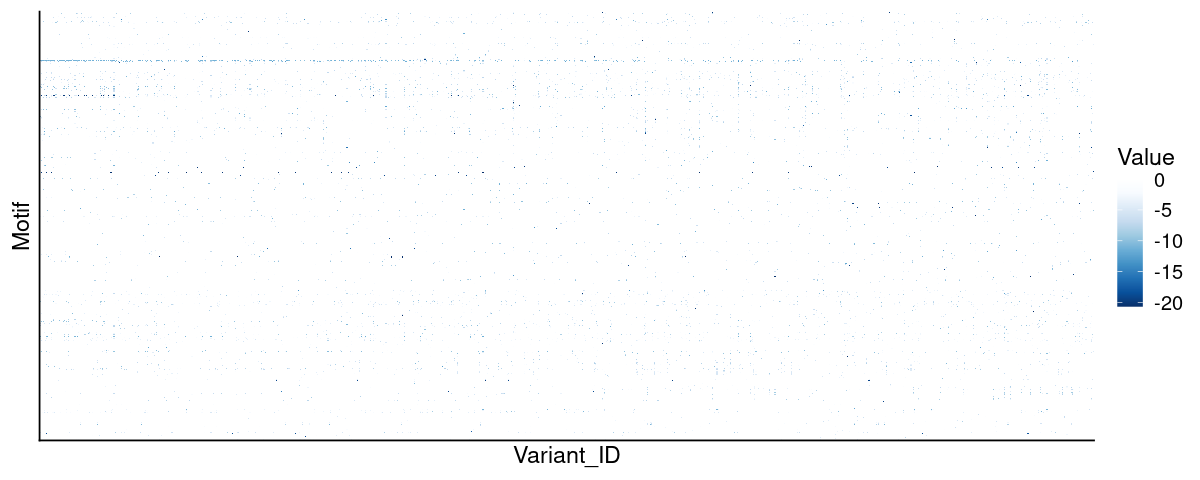

In [123]:
###
dat = dat_X_loss_subset
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_loss = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

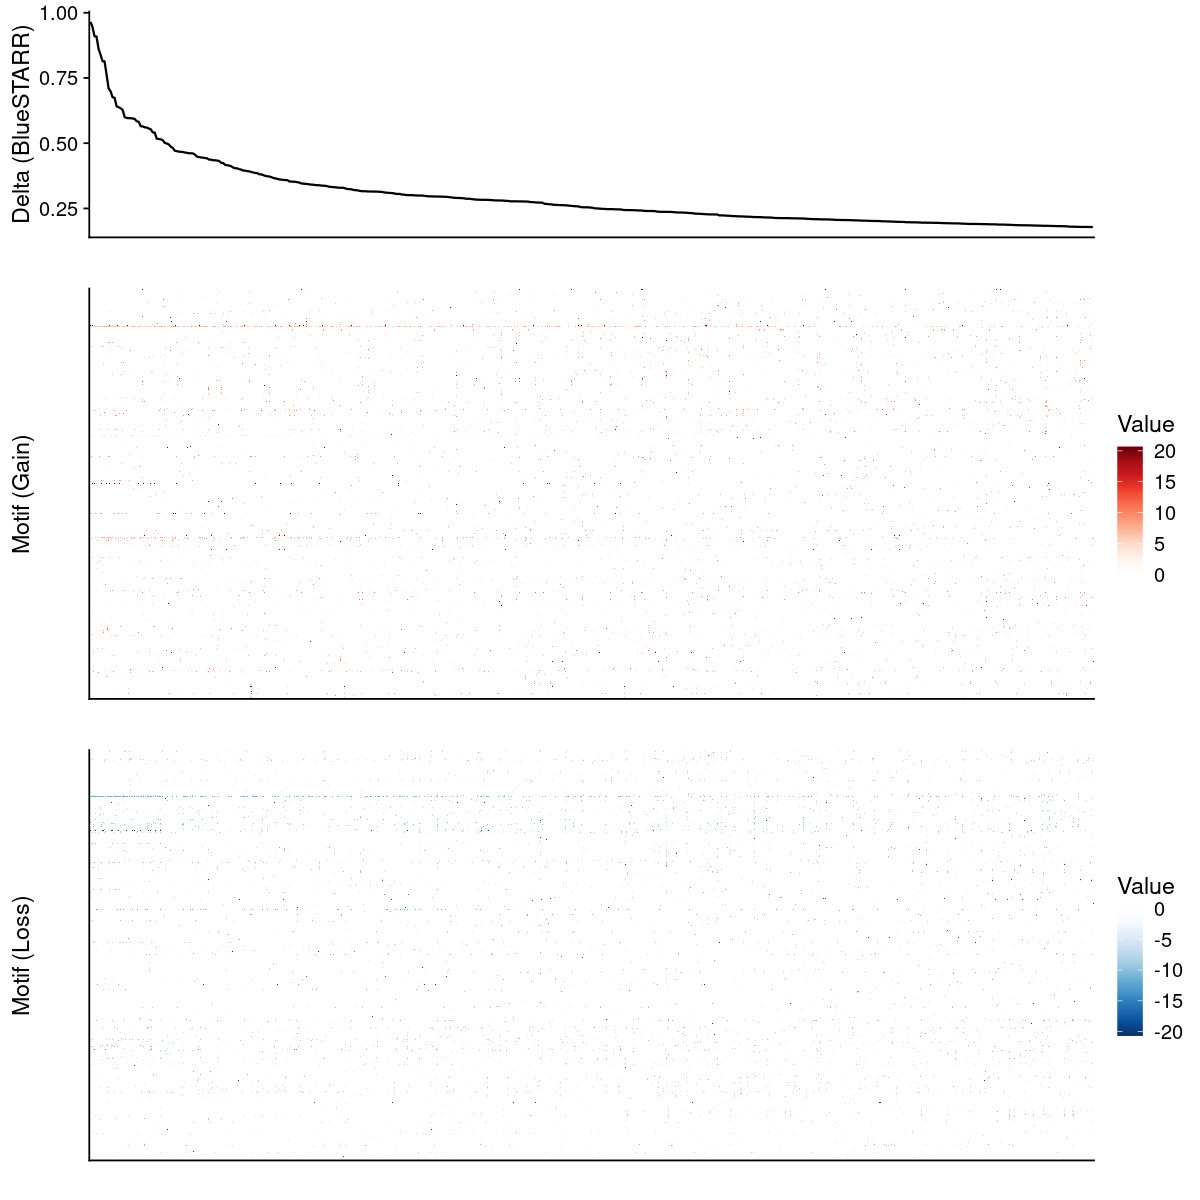

In [124]:
lst = list(
    gpt_Y      + labs(x="", y = "Delta (BlueSTARR)"), 
    gpt_X_gain + labs(x="", y = "Motif (Gain)"), 
    gpt_X_loss + labs(x="", y = "Motif (Loss)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(3, 5, 5),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=10)
print(plt)

In [114]:
head(dat_X_gain_subset)

Variant_ID,Motif,Value
<chr>,<chr>,<dbl>
chr4:74487586:A:G:C,AC0048:NFE2L/JUN:bZIP,1.914324
chr4:74487586:A:G:C,AC0116:THRB/ESRRA:Nuclear_receptor,6.131183
chr4:74487586:A:G:C,AC0125:NR1I/VDR:Nuclear_receptor,6.838040
chr4:74487586:A:G:C,"AC0158:PAX:Homeodomain,Paired_box",0.916502
chr4:74487586:A:G:C,AC0219:ZNF:C2H2_ZF,3.162317
chr4:74487586:A:G:C,AC0270:FOXN:Forkhead,14.101768


In [115]:
dat = dat_motif_activator
vec = dat$variable
vec = head(vec, 30)
vec_txt_motif_activator = vec

dat = dat_motif_repressor
vec = dat$variable
vec = head(vec, 30)
vec_txt_motif_repressor = vec

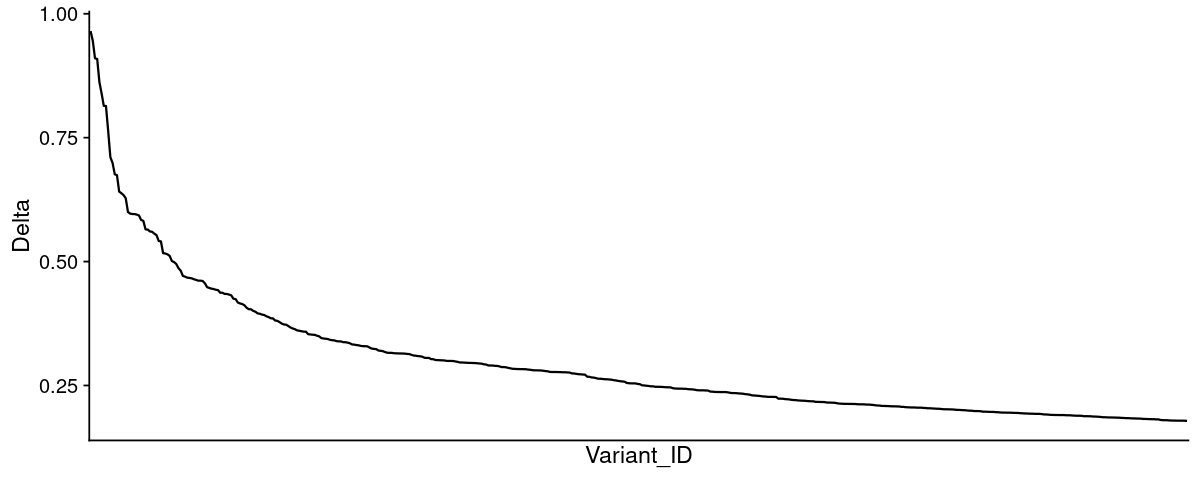

In [134]:
dat = dat_region_variant
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_top)
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

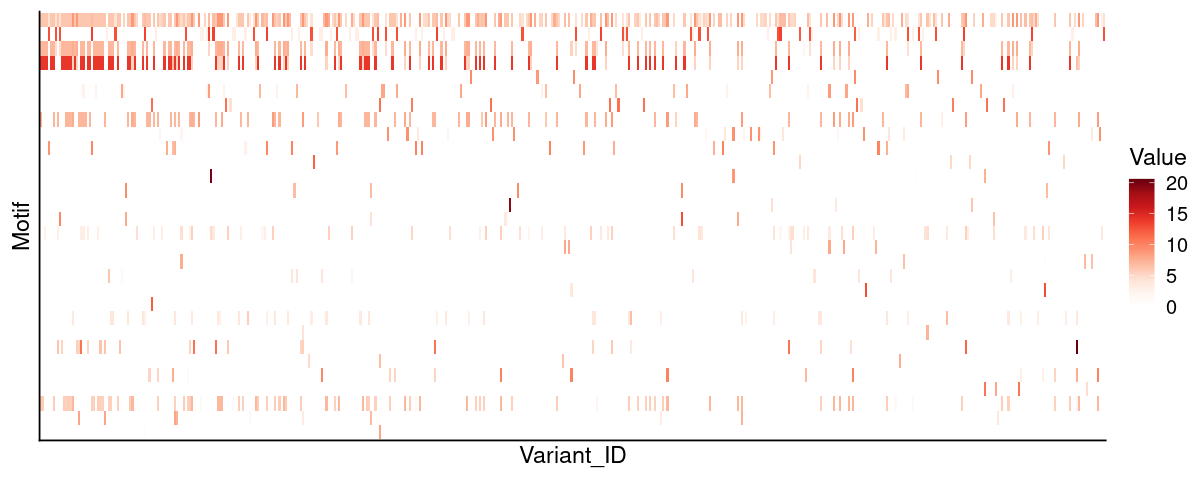

In [135]:
###
dat = dat_X_gain_top
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_activator)
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    Motif      = factor(Motif,      levels=rev(vec_txt_motif_activator))
)

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_gain = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

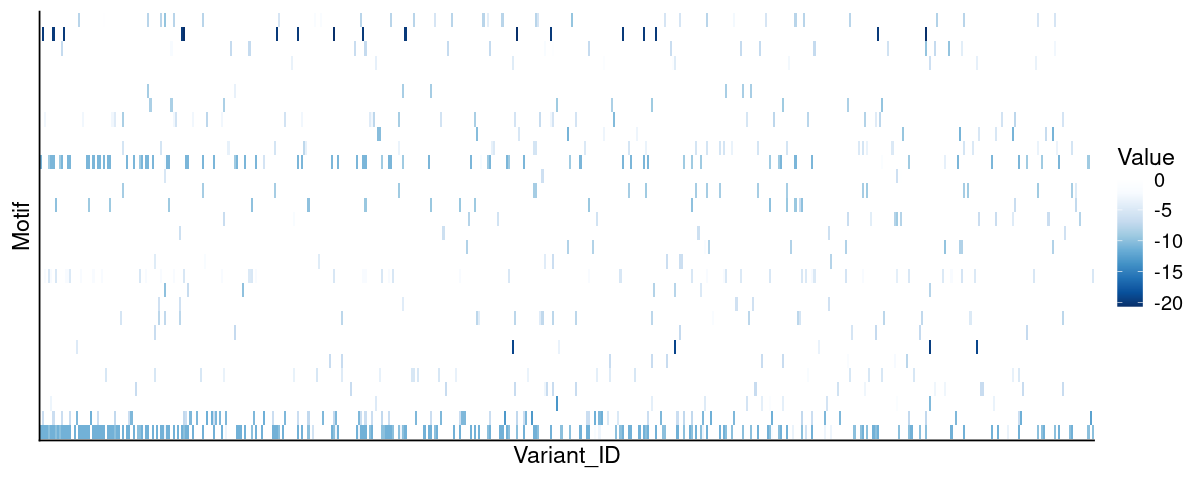

In [136]:
###
dat = dat_X_loss_top
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_repressor)
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    Motif      = factor(Motif,      levels=vec_txt_motif_repressor)
)

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_loss = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

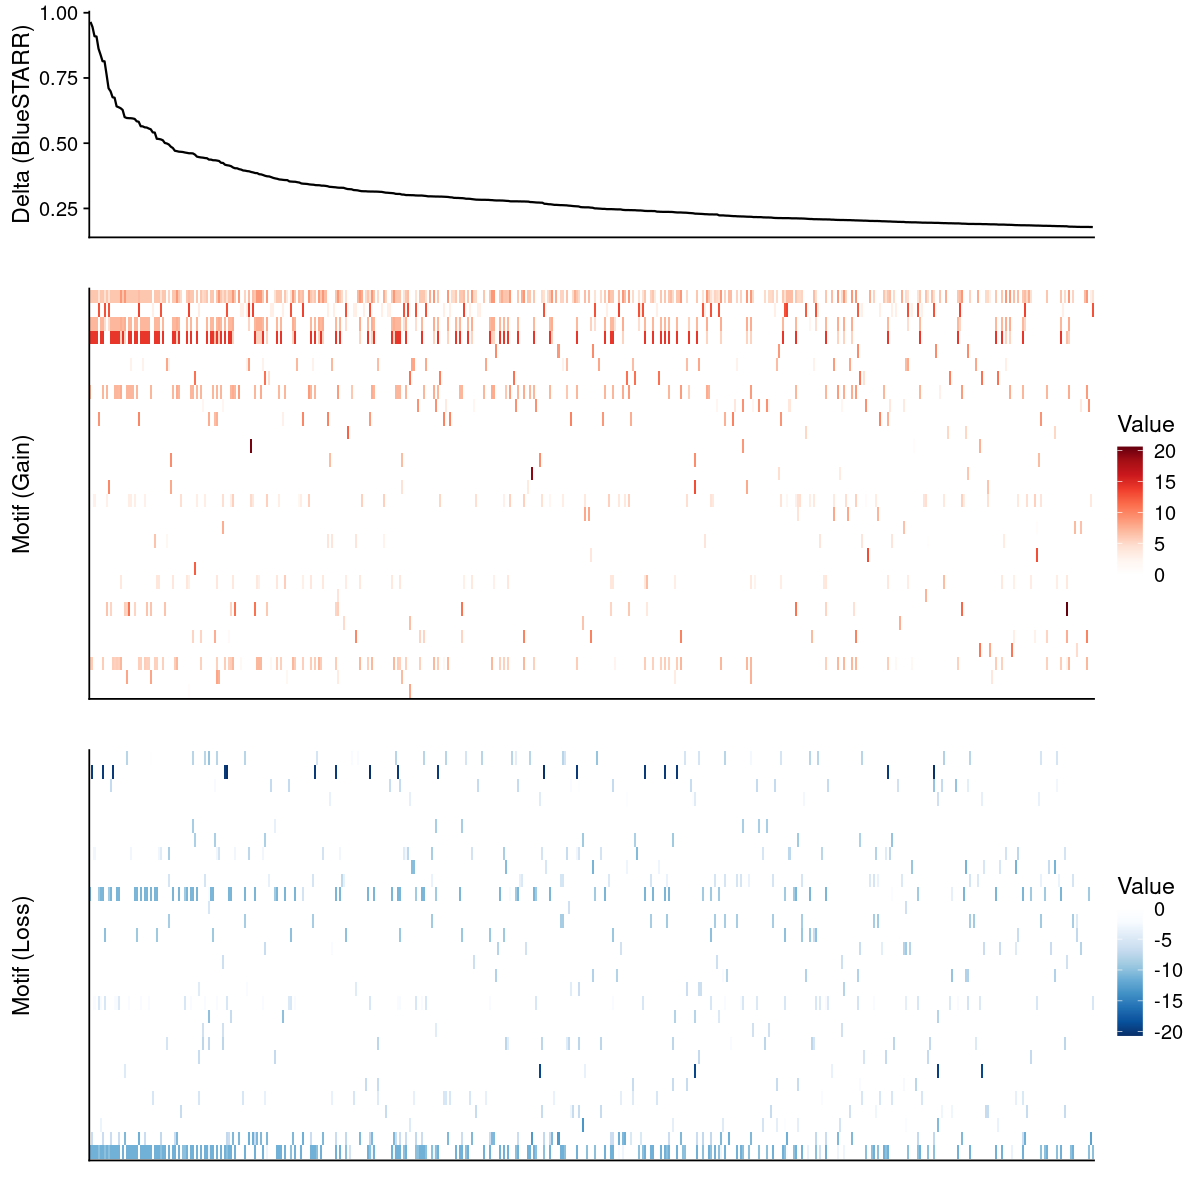

In [137]:
lst = list(
    gpt_Y      + labs(x="", y = "Delta (BlueSTARR)"), 
    gpt_X_gain + labs(x="", y = "Motif (Gain)"), 
    gpt_X_loss + labs(x="", y = "Motif (Loss)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(3, 5, 5),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=10)
print(plt)

In [143]:
dat = dat_motif_activator
vec = dat$variable
vec = head(vec, 30)
vec_txt_motif_activator = vec

dat = dat_motif_repressor
vec = dat$variable
vec = head(vec, 30)
vec_txt_motif_repressor = vec

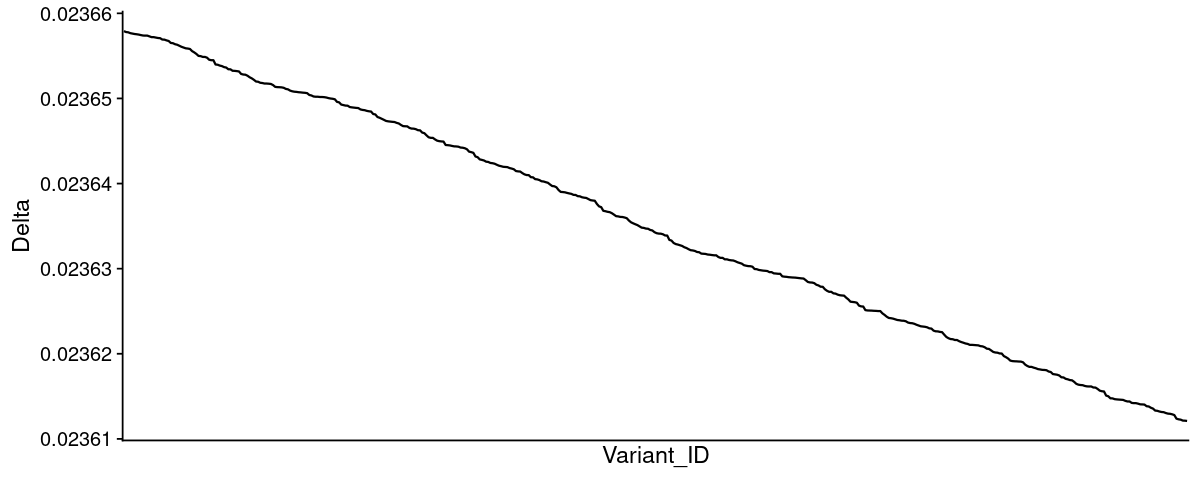

In [144]:
dat = dat_region_variant
dat = dat %>% dplyr::filter(Variant_ID %in% vec_txt_variant_low)
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

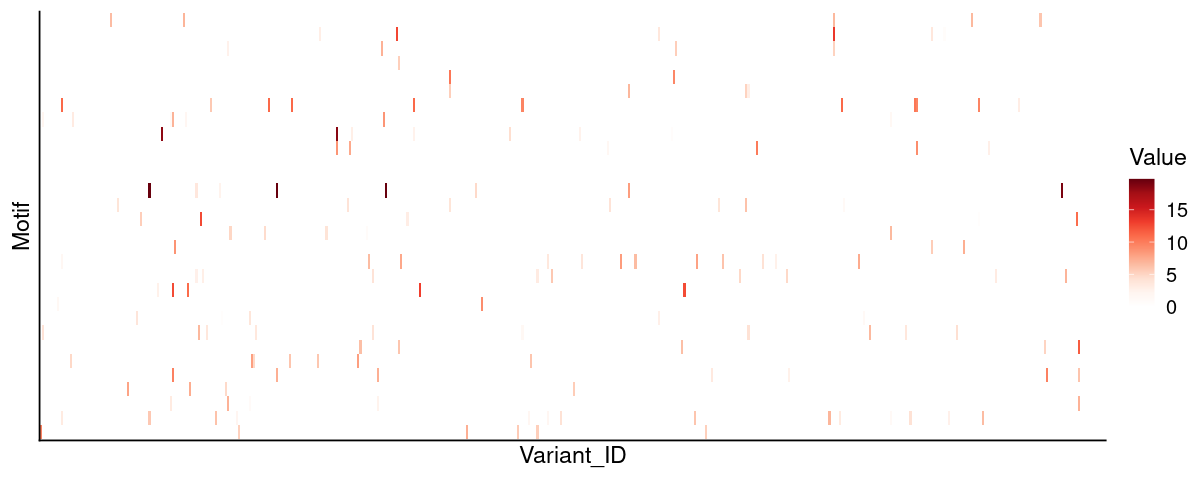

In [146]:
###
dat = dat_X_gain_low
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_activator)
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    Motif      = factor(Motif,      levels=rev(vec_txt_motif_activator))
)

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_gain = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

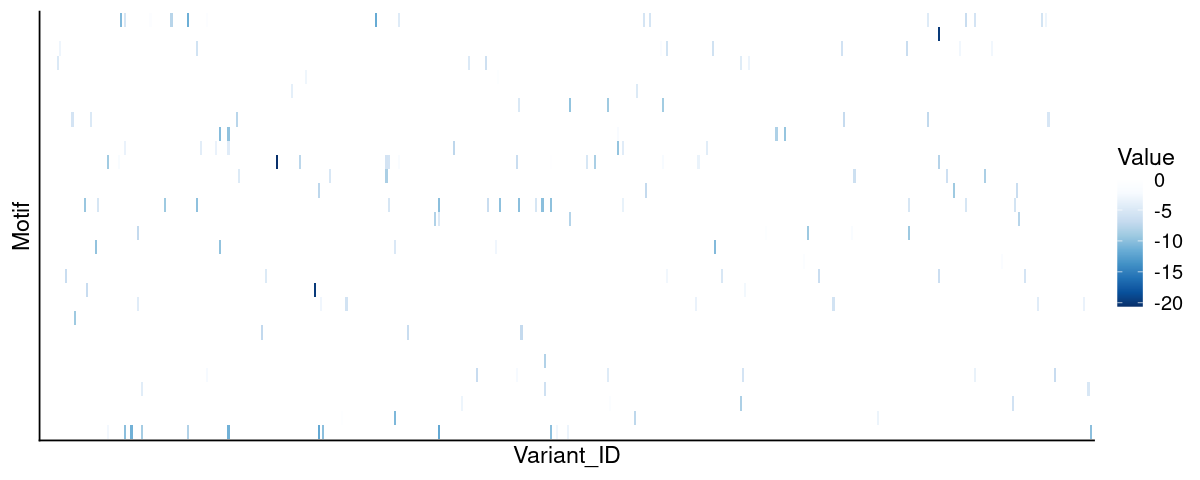

In [147]:
###
dat = dat_X_loss_low
dat = dat %>% dplyr::filter(Motif %in% vec_txt_motif_repressor)
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    Motif      = factor(Motif,      levels=vec_txt_motif_repressor)
)

###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    axis.text.y  = element_blank(),
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = Value)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color)

###
gpt_X_loss = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

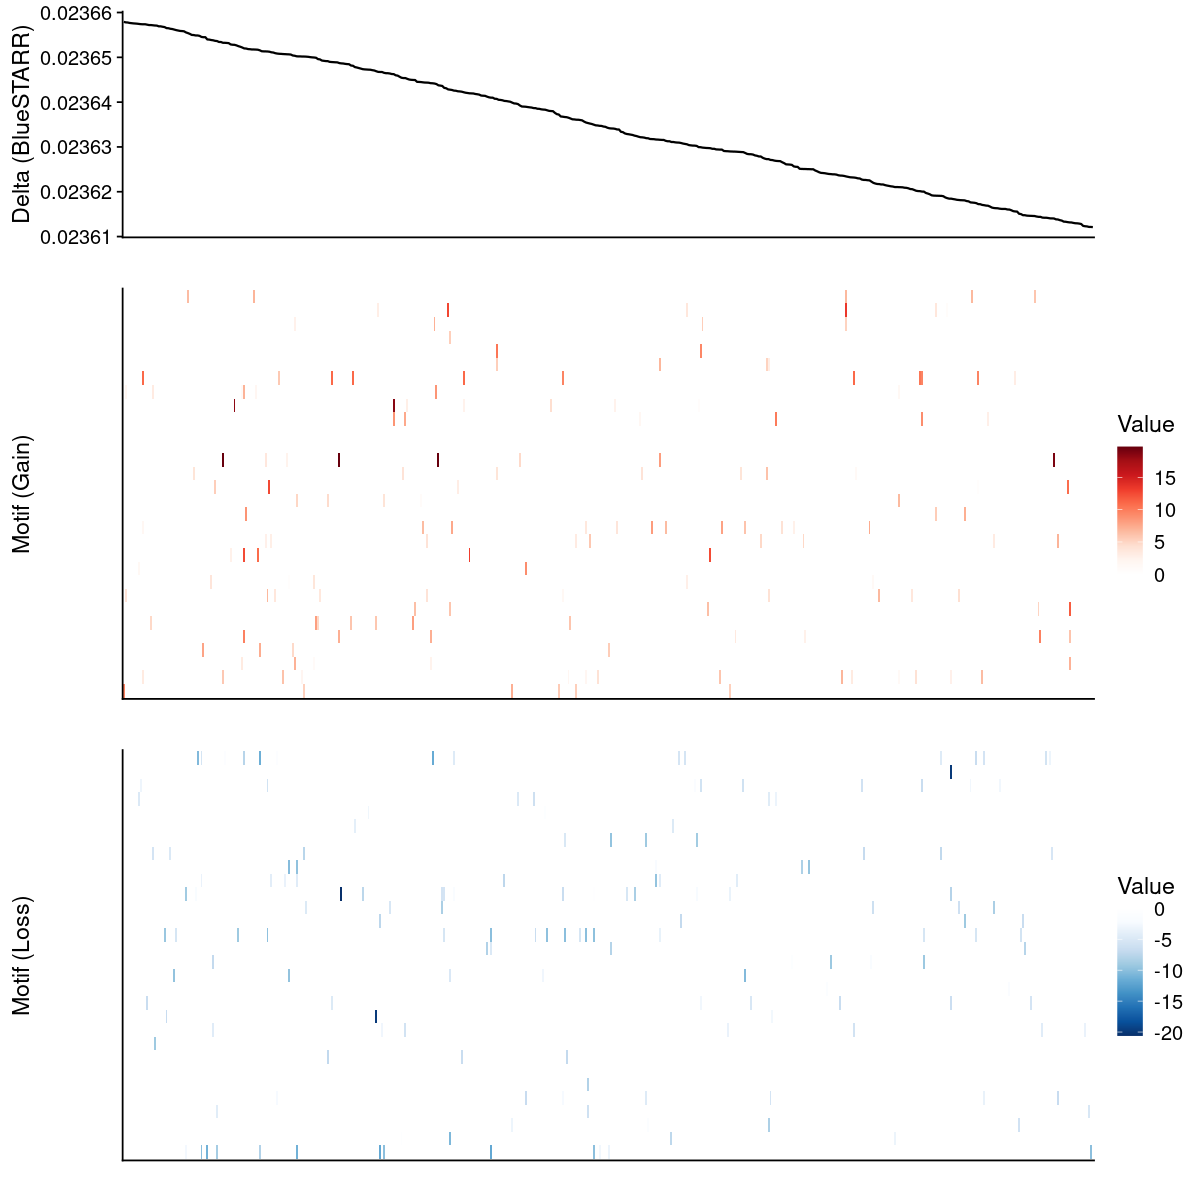

In [148]:
lst = list(
    gpt_Y      + labs(x="", y = "Delta (BlueSTARR)"), 
    gpt_X_gain + labs(x="", y = "Motif (Gain)"), 
    gpt_X_loss + labs(x="", y = "Motif (Loss)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(3, 5, 5),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=10)
print(plt)